In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import torch
import sys, os
%matplotlib inline
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ''))
from cmb.simulators import BmodeSimulator128

shape: (128, 128), mean: 0.0881, rms: 70.8941


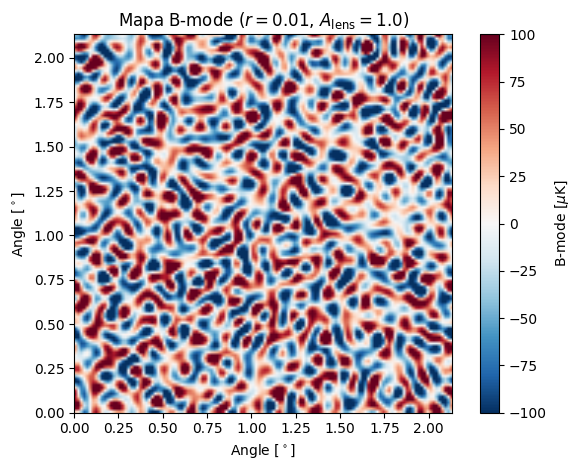

In [27]:
sim = BmodeSimulator128()

theta = torch.tensor([0.01, 1.0])
x = sim.simulate(theta, seed=42)

N = 128
pix_size = 1.0
Xw = N * pix_size / 60.0

mapa = x.numpy().reshape(N, N)

print(f"shape: {mapa.shape}, mean: {mapa.mean():.4f}, rms: {mapa.std():.4f}")

plt.imshow(mapa, interpolation='bilinear', origin='lower', cmap=cm.RdBu_r,
           vmin=-100, vmax=100, extent=[0, Xw, 0, Xw])
plt.colorbar(label=r'B-mode [$\mu$K]')
plt.xlabel(r'Angle $[^\circ]$')
plt.ylabel(r'Angle $[^\circ]$')
plt.title(r'Mapa B-mode ($r=0.01$, $A_{\mathrm{lens}}=1.0$)')
plt.tight_layout()
plt.show()

## Batch de sims

In [28]:
theta_batch = torch.tensor([[0.0, 1.0],
                            [0.7, 1.0],
                            [0.14, 1.0],
                            [0.2, 1.0]])
x_batch = sim(theta_batch, show_progress=True)
print(f"batch shape: {x_batch.shape}")

Simulating: 100%|██████████| 4/4 [00:00<00:00, 345.72it/s]

batch shape: torch.Size([4, 16384])


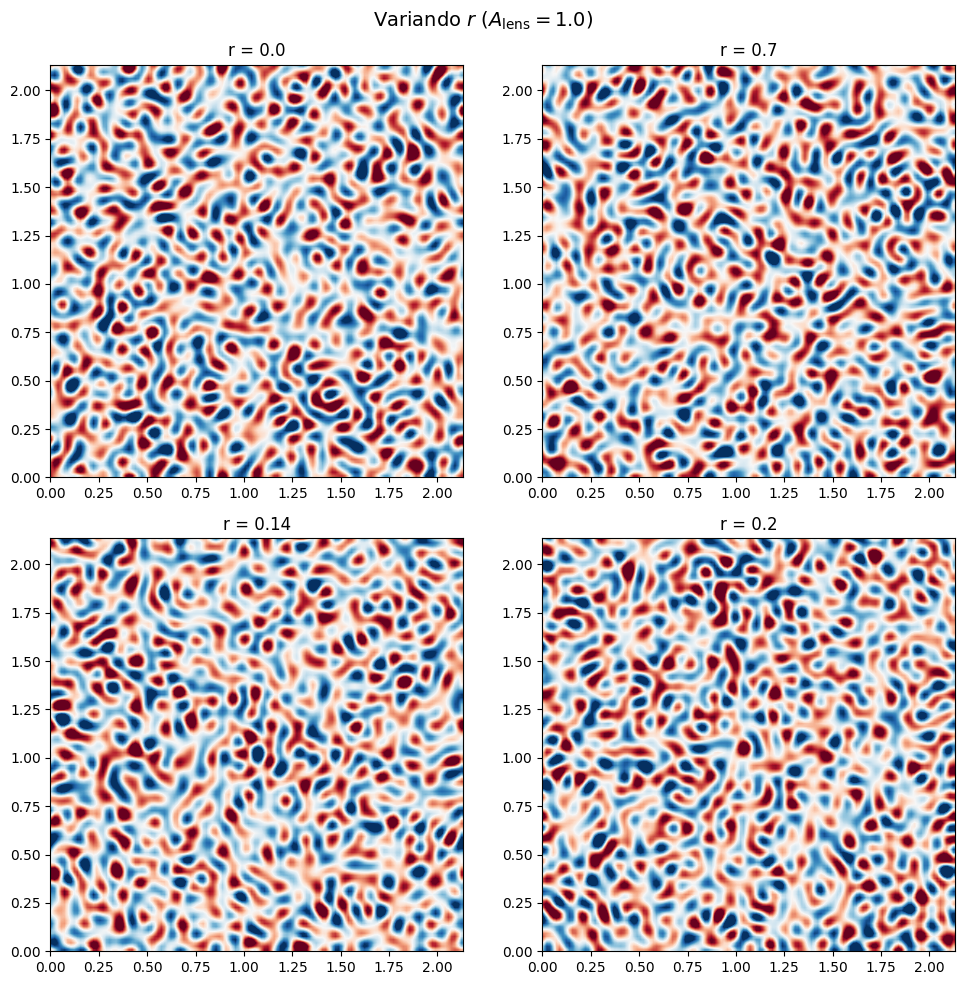

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
r_vals = [0.0, 0.7, 0.14, 0.2]
for ax, r_val, x_row in zip(axes.flat, r_vals, x_batch):
    m = x_row.numpy().reshape(N, N)
    ax.imshow(m, interpolation='bilinear', origin='lower', cmap=cm.RdBu_r,
              vmin=-130, vmax=130, extent=[0, Xw, 0, Xw])
    ax.set_title(f'r = {r_val}')
plt.suptitle(r'Variando $r$ ($A_{\mathrm{lens}} = 1.0$)', fontsize=14)
plt.tight_layout()
plt.show()

In [30]:
theta_batch = torch.tensor([[0.05, 0.0],
                            [0.05, 1.0],
                            [0.05, 2.0],
                            [0.05, 3.0]])
x_batch = sim(theta_batch, show_progress=True)
print(f"batch shape: {x_batch.shape}")

Simulating: 100%|██████████| 4/4 [00:00<00:00, 282.60it/s]

batch shape: torch.Size([4, 16384])


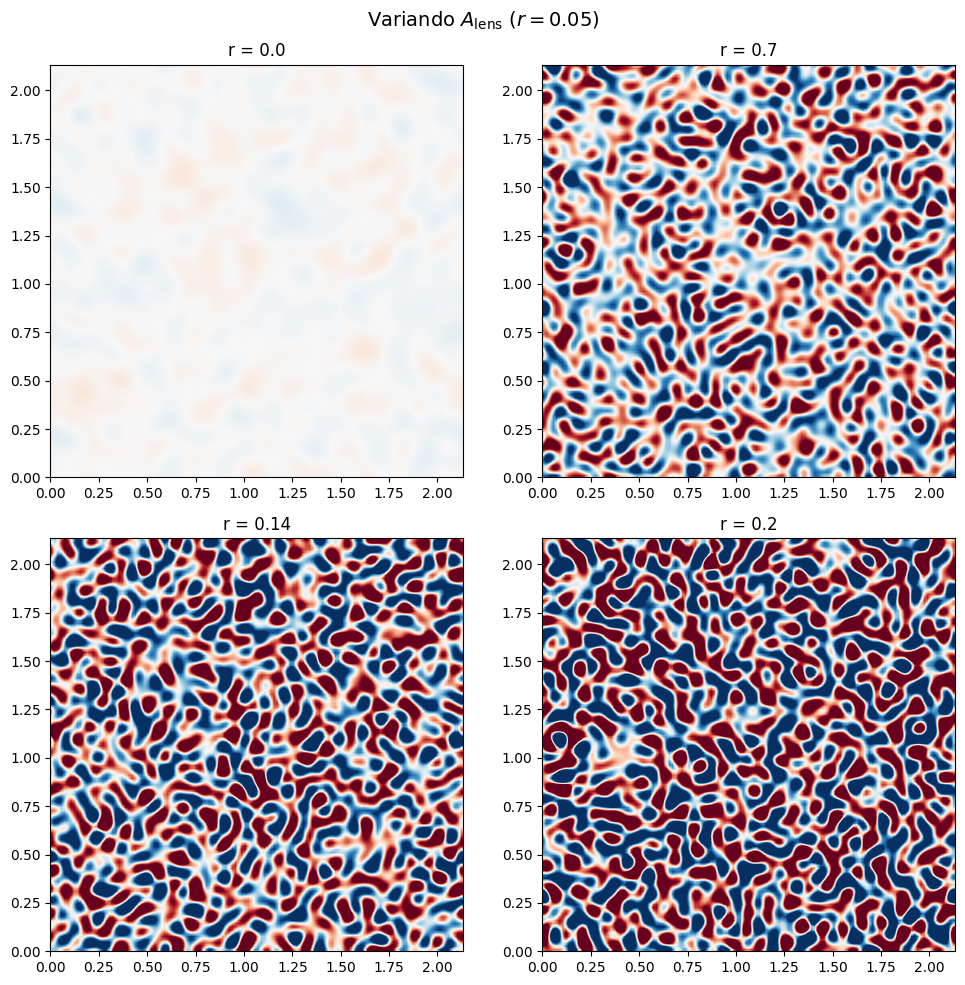

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
r_vals = [0.0, 0.7, 0.14, 0.2]
for ax, r_val, x_row in zip(axes.flat, r_vals, x_batch):
    m = x_row.numpy().reshape(N, N)
    ax.imshow(m, interpolation='bilinear', origin='lower', cmap=cm.RdBu_r,
              vmin=-100, vmax=100, extent=[0, Xw, 0, Xw])
    ax.set_title(f'r = {r_val}')
plt.suptitle(r'Variando $A_{\mathrm{lens}}$ ($r = 0.05$)', fontsize=14)
plt.tight_layout()
plt.show()

## simulate_obs con seed fija

Usando `simulate_obs` con seed determinada para reproducibilidad.

x_o shape: torch.Size([1, 16384])


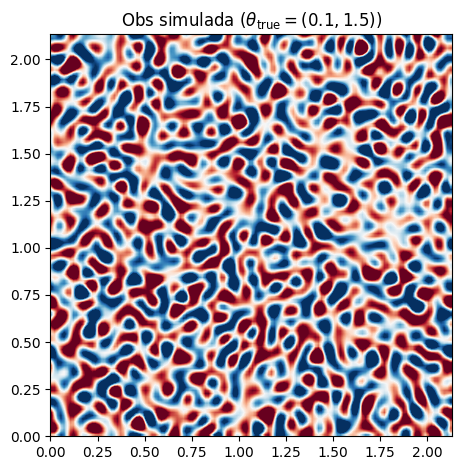

In [32]:
from zbi.pipeline import simulate_obs

x_o = simulate_obs(sim, theta_true=(0.1, 1.5), seed=42)
print(f"x_o shape: {x_o.shape}")

mapa_o = x_o.numpy().reshape(N, N)
plt.imshow(mapa_o, interpolation='bilinear', origin='lower', cmap=cm.RdBu_r,
           vmin=-100, vmax=100, extent=[0, Xw, 0, Xw])
plt.title(r'Obs simulada ($\theta_{\mathrm{true}} = (0.1, 1.5)$)')
plt.tight_layout()
plt.show()

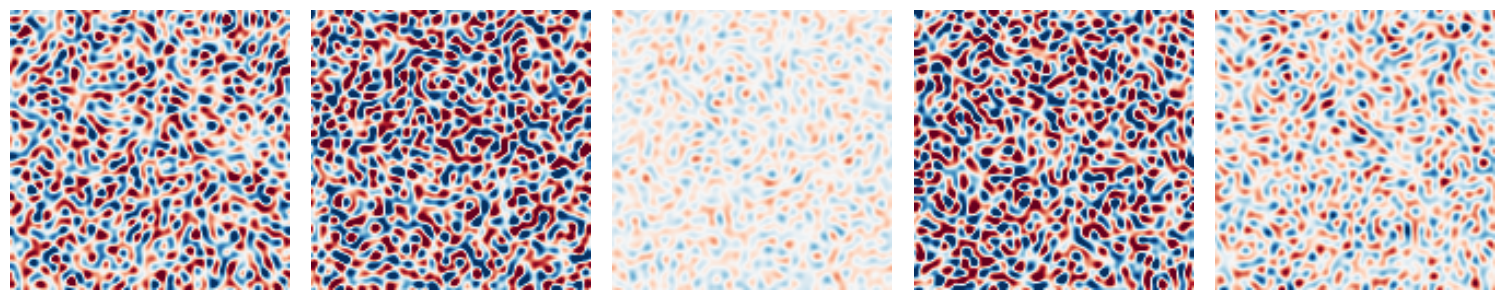

In [46]:
n_prior = 4
r_vals = torch.distributions.Uniform(0.0, 0.2).sample((n_prior,))
Al_vals = torch.distributions.Uniform(0.0, 3.0).sample((n_prior,))
theta_prior = torch.stack([r_vals, Al_vals], dim=1)

fig, axes = plt.subplots(1, 1 + n_prior, figsize=(3*(1+n_prior), 2.8))

# primera: x_o
m = x_o.numpy().reshape(128, 128)
axes[0].imshow(m, interpolation="bilinear", origin="lower", cmap=cm.RdBu_r,
              vmin=-150, vmax=150)
axes[0].axis("off")

# resto: samples del prior
for ax, th in zip(axes[1:], theta_prior):
    x = sim.simulate(th, seed=None)
    m = x.numpy().reshape(128, 128)
    ax.imshow(m, interpolation="bilinear", origin="lower", cmap=cm.RdBu_r,
              vmin=-150, vmax=150)
    ax.axis("off")

plt.subplots_adjust(wspace=0.02, hspace=0, left=0, right=1, bottom=0, top=1)
plt.show()


theta samples (r, A_lens):
  r=0.1399  A_lens=1.4535
  r=0.0093  A_lens=1.4142
  r=0.1374  A_lens=1.5534
  r=0.0749  A_lens=1.6273


Simulating: 100%|██████████| 4/4 [00:00<00:00, 466.76it/s]


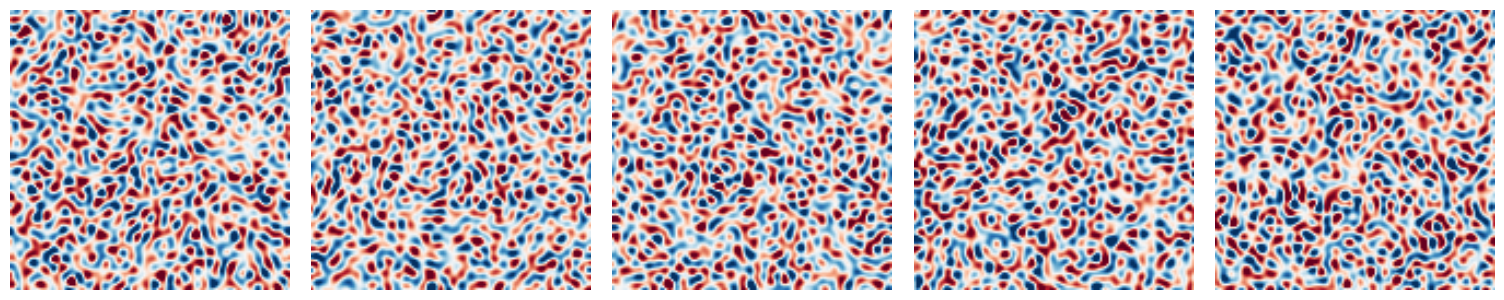

In [34]:
from zbi.utils.checkpoint import load_checkpoint, load_maf_from_checkpoint
from zbi.pipeline._resolve import resolve_class
from zbi.inference.posterior import Posterior
from torch.distributions import Uniform

run_dir = "runs/bmode128"
device = "cpu"
sim = BmodeSimulator128()

# cargar MAF
ckpt = load_checkpoint(f"../{run_dir}/models/round_00000_1000.pt")
emb_config = ckpt["embedding_net_config"]
emb_class = resolve_class(emb_config["class"])
emb_kwargs = {k: v for k, v in emb_config.items() if k != "class"}
maf = load_maf_from_checkpoint(ckpt, embedding_net=emb_class(**emb_kwargs)).to(device)

# posterior
prior = Uniform(torch.tensor([0.0, 0.0]), torch.tensor([0.2, 3.0]))
posterior = Posterior(maf, prior, device=device, enable_leakage_correction=False)

# x_o
x_o = torch.load(f"../{run_dir}/x_o.pt", weights_only=True).to(device)

# samplear theta de la posterior
theta_post = posterior.sample((4,), x_o, max_sampling_batch_size=1000, sample_batch_size=256)
print("theta samples (r, A_lens):")
for th in theta_post:
    print(f"  r={th[0]:.4f}  A_lens={th[1]:.4f}")

# simular mapas para esos theta (ruido nuevo cada vez, seed=None)
theta_post = torch.as_tensor(theta_post, dtype=torch.float32)
maps = sim(theta_post)

# plot 1x5: x_o + 4 posterior samples
fig, axes = plt.subplots(1, 5, figsize=(15, 2.8))
m = x_o.cpu().numpy().reshape(128, 128)
axes[0].imshow(m, interpolation="bilinear", origin="lower", cmap=cm.RdBu_r,
               vmin=-150, vmax=150)
axes[0].axis("off")
for ax, row in zip(axes[1:], maps):
    m = row.numpy().reshape(128, 128)
    ax.imshow(m, interpolation="bilinear", origin="lower", cmap=cm.RdBu_r,
              vmin=-150, vmax=150)
    ax.axis("off")
plt.subplots_adjust(wspace=0.02, hspace=0, left=0, right=1, bottom=0, top=1)
plt.show()
